In [164]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [165]:
df = pd.read_csv("loan_data.csv")

In [166]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [167]:
df.shape

(45000, 14)

In [168]:
df.dtypes

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

### Perfect non null data

### Checking dataset of each column

In [170]:
df["person_age"].unique()

array([ 22.,  21.,  25.,  23.,  24.,  26., 144., 123.,  20.,  32.,  34.,
        29.,  33.,  28.,  35.,  31.,  27.,  30.,  36.,  40.,  50.,  45.,
        37.,  39.,  44.,  43.,  41.,  46.,  38.,  47.,  42.,  48.,  49.,
        58.,  65.,  51.,  53.,  66.,  61.,  54.,  57.,  59.,  62.,  60.,
        55.,  52.,  64.,  70.,  78.,  69.,  56.,  73.,  63.,  94.,  80.,
        84.,  76.,  67., 116., 109.])

In [171]:
df["person_age"] = df["person_age"].astype(int)

In [172]:
### Remove 116 and 109 age

In [173]:
df["person_gender"].unique()

array(['female', 'male'], dtype=object)

In [174]:
df["person_education"].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [175]:
education_order = [
    "High School",
    "Associate",
    "Bachelor",
    "Master",
    "Doctorate"
]

In [176]:
df["person_income"] = df["person_income"].astype(int)

In [177]:
df["person_emp_exp"].unique()

array([  0,   3,   1,   5,   4,   2,   7,   6, 125,   8, 121, 101, 100,
        12,  10,   9,  14,  13,  11,  15,  16,  17,  19,  28,  25,  18,
        24,  22,  20,  23,  21,  31,  26,  27,  29,  32,  30, 124,  40,
        43,  33,  44,  34,  42,  37,  45,  36,  41,  47,  38,  39,  35,
        57,  46,  49,  48,  50,  76,  62,  61,  58,  93,  85])

In [178]:
df["person_home_ownership"].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [179]:
df["loan_amnt"].unique()

array([35000.,  1000.,  5500., ..., 12229.,  2771.,  6665.])

In [180]:
df["loan_amnt"] = df["loan_amnt"].astype(int)

In [181]:
df["loan_intent"].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [182]:
df["loan_int_rate"].value_counts()

loan_int_rate
11.01    3329
10.99     804
7.51      798
7.49      687
7.88      673
         ... 
16.20       1
18.44       1
19.39       1
18.68       1
16.92       1
Name: count, Length: 1302, dtype: int64

In [183]:
df["loan_int_rate"] = df["loan_int_rate"].astype(float)

In [184]:
df["loan_percent_income"].unique()

array([0.49, 0.08, 0.44, 0.53, 0.19, 0.37, 0.35, 0.13, 0.34, 0.3 , 0.27,
       0.25, 0.05, 0.24, 0.31, 0.26, 0.12, 0.18, 0.21, 0.43, 0.11, 0.4 ,
       0.32, 0.1 , 0.41, 0.22, 0.07, 0.02, 0.17, 0.51, 0.38, 0.33, 0.06,
       0.03, 0.28, 0.04, 0.09, 0.2 , 0.23, 0.15, 0.48, 0.5 , 0.14, 0.42,
       0.01, 0.46, 0.29, 0.39, 0.36, 0.16, 0.  , 0.57, 0.45, 0.52, 0.55,
       0.61, 0.62, 0.66, 0.54, 0.47, 0.56, 0.58, 0.63, 0.59])

In [185]:
df["cb_person_cred_hist_length"].unique()

array([ 3.,  2.,  4.,  8.,  7.,  6.,  9., 10.,  5., 11., 16., 15., 12.,
       13., 17., 14., 25., 28., 27., 22., 19., 29., 23., 26., 20., 21.,
       30., 24., 18.])

In [186]:
df["cb_person_cred_hist_length"] = df["cb_person_cred_hist_length"].astype(float)

In [187]:
df["credit_score"].unique()

array([561, 504, 635, 675, 586, 532, 701, 585, 544, 640, 621, 651, 573,
       708, 583, 670, 663, 694, 709, 679, 684, 662, 691, 600, 654, 626,
       607, 700, 553, 589, 681, 567, 669, 606, 582, 649, 602, 616, 631,
       637, 695, 620, 622, 645, 624, 570, 648, 652, 559, 623, 609, 579,
       688, 661, 562, 664, 564, 598, 557, 677, 690, 599, 604, 601, 634,
       671, 789, 538, 587, 683, 518, 617, 668, 673, 706, 536, 689, 595,
       584, 642, 614, 597, 625, 603, 643, 508, 505, 593, 686, 646, 697,
       615, 687, 650, 588, 658, 531, 665, 703, 594, 618, 574, 577, 653,
       630, 660, 639, 612, 628, 592, 580, 678, 672, 613, 566, 718, 484,
       699, 656, 659, 636, 554, 807, 578, 674, 608, 569, 629, 560, 548,
       667, 676, 581, 655, 551, 529, 666, 576, 633, 611, 657, 647, 542,
       692, 545, 540, 525, 537, 641, 539, 563, 712, 491, 590, 572, 528,
       638, 627, 596, 547, 507, 565, 693, 522, 632, 556, 499, 704, 503,
       714, 552, 555, 558, 521, 605, 571, 591, 719, 610, 535, 64

In [188]:
df["previous_loan_defaults_on_file"].unique()

array(['No', 'Yes'], dtype=object)

In [189]:
df["loan_status"].unique()

array([1, 0])

### Univariate analysis

In [190]:
numeric_cols = df.select_dtypes(include=["number"]).columns

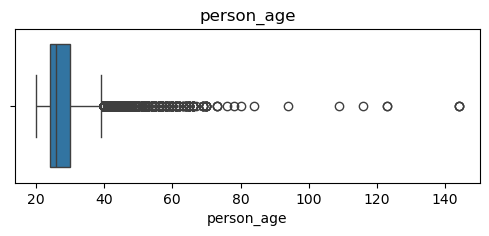

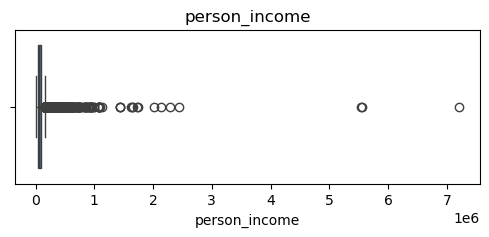

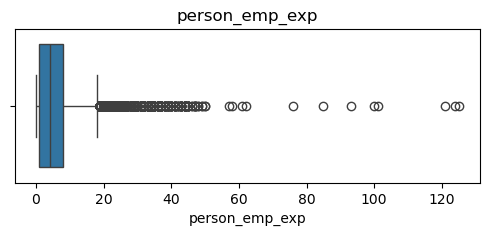

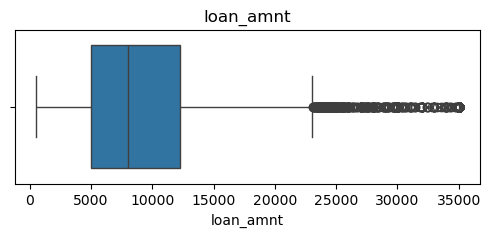

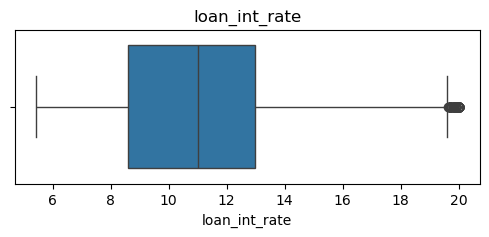

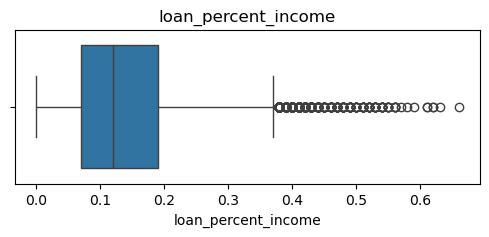

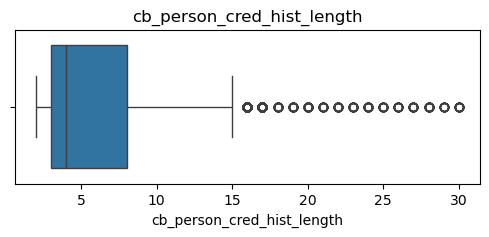

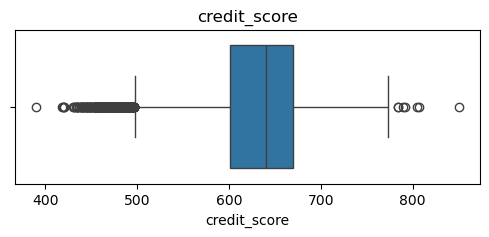

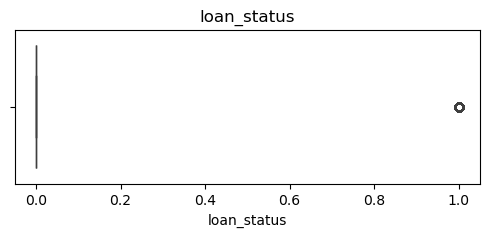

In [191]:
for col in numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [192]:
le = LabelEncoder()
le.fit_transform(df["loan_status"])
order = OrdinalEncoder()
encoder = OrdinalEncoder(categories=[education_order])
df["person_education"] = encoder.fit_transform(df[["person_education"]])

In [193]:

nominal_cols = [
    "person_home_ownership",
    "loan_intent",
    "person_gender",
    "previous_loan_defaults_on_file"
    
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded = encoder.fit_transform(df[nominal_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=df.index
)

df = pd.concat([df.drop(columns=nominal_cols), encoded_df], axis=1)

In [194]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [195]:
X_train_raw,X_test_raw,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [196]:
lr = LogisticRegression()
lr.fit(X_train_raw,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [197]:
y_pred = lr.predict(X_test_raw)

In [198]:
print(accuracy_score(y_test,y_pred))

0.8275555555555556


In [199]:
dr = DecisionTreeClassifier()

In [200]:
dr.fit(X_train_raw,y_train)
y_pred2 = dr.predict(X_test_raw)
print(accuracy_score(y_test,y_pred2))

0.8993333333333333
